<a href="https://colab.research.google.com/github/hk666890/SEM-VI--A2/blob/main/IPMV_Exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

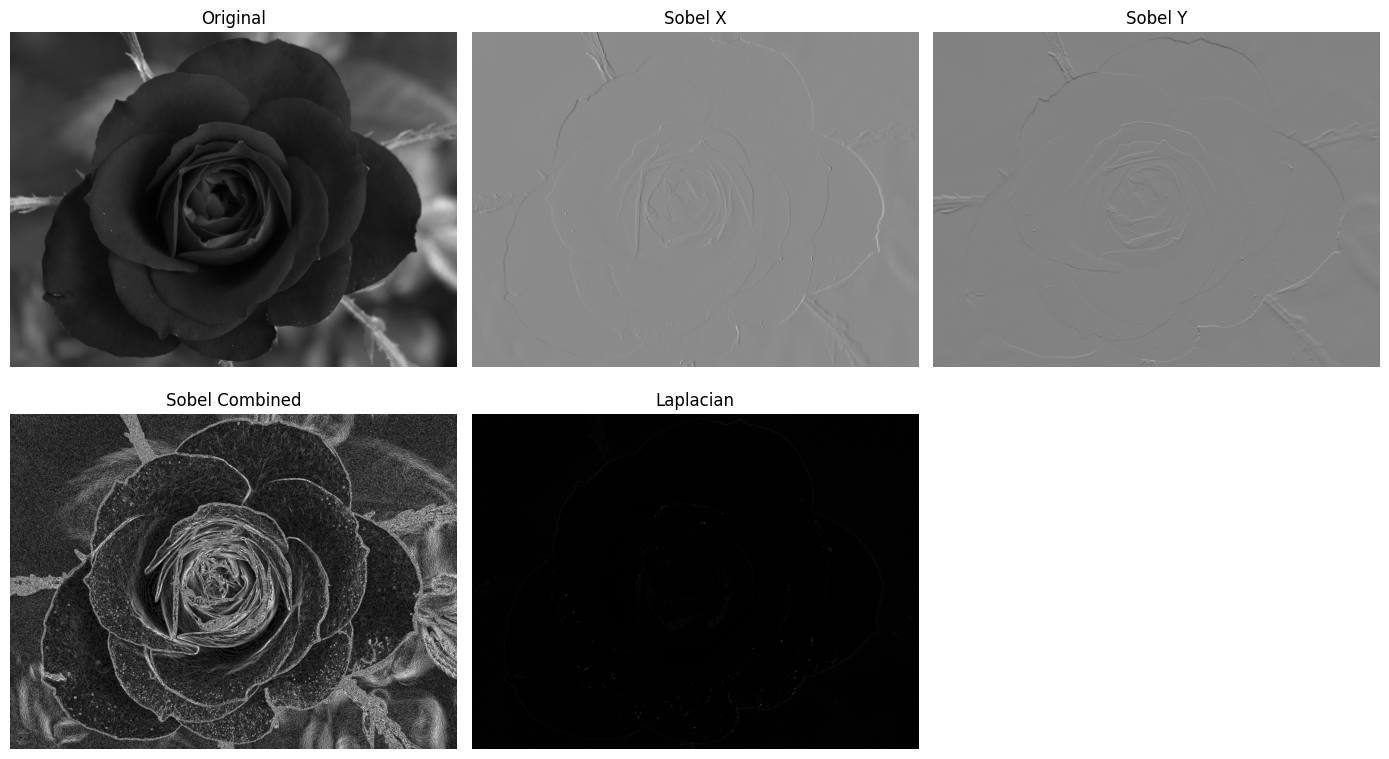

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

def exp3_edge_detection():
    # Download image
    url = "https://upload.wikimedia.org/wikipedia/commons/5/51/Small_Red_Rose.JPG"

    # Add User-Agent header to mimic a browser request
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    req = urllib.request.Request(url, headers=headers)

    try:
        with urllib.request.urlopen(req) as response:
            with open("rose.png", "wb") as out_file:
                out_file.write(response.read())
    except urllib.error.HTTPError as e:
        print(f"HTTP Error: {e.code} - {e.reason}")
        print(f"Could not download image from {url}")
        return

    # Read grayscale image
    img = cv2.imread("rose.png", 0)

    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from rose.png, even after download attempt.")
        return

    # --------------------------------------------------------
    # Sobel Edge Detection
    # --------------------------------------------------------
    # Sobel X detects vertical edges
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
    # Sobel Y detects horizontal edges
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
    # Combine Sobel X and Y
    sobel_combined = np.uint8(cv2.magnitude(sobelx, sobely))

    # --------------------------------------------------------
    # Laplacian Edge Detection
    # --------------------------------------------------------
    laplacian = np.uint8(np.absolute(cv2.Laplacian(img, cv2.CV_64F)))

    # --------------------------------------------------------
    # Display Results
    # --------------------------------------------------------
    images = [img, sobelx, sobely, sobel_combined, laplacian]
    titles = ["Original", "Sobel X", "Sobel Y", "Sobel Combined", "Laplacian"]

    plt.figure(figsize=(14, 8))
    for i in range(len(images)):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

exp3_edge_detection()